In [ ]:
# Step 1: Install Louvain library
!pip install python-louvain

# Step 2: Libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import community.community_louvain as community_louvain  # ✅ ¡Correct import!

from google.colab import files
uploaded = files.upload()  # file FW_functional.csv

# Step 3: Add file CSV
df = pd.read_csv(next(iter(uploaded)))

# Step 4: Create the directed graph
G = nx.DiGraph()
edges = list(df.itertuples(index=False, name=None))
G.add_edges_from(edges)

# Step 5: Calculate basic metrics
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
connectance = num_edges / (num_nodes * (num_nodes - 1))

# Step 6: Convert to an undirected graph to calculate modularity using Louvain
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)
modularity = community_louvain.modularity(partition, G_undirected)

centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

Saving Red_funcional_colapsada.csv to Red_funcional_colapsada.csv


/tmp/ipython-input-2242200641.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


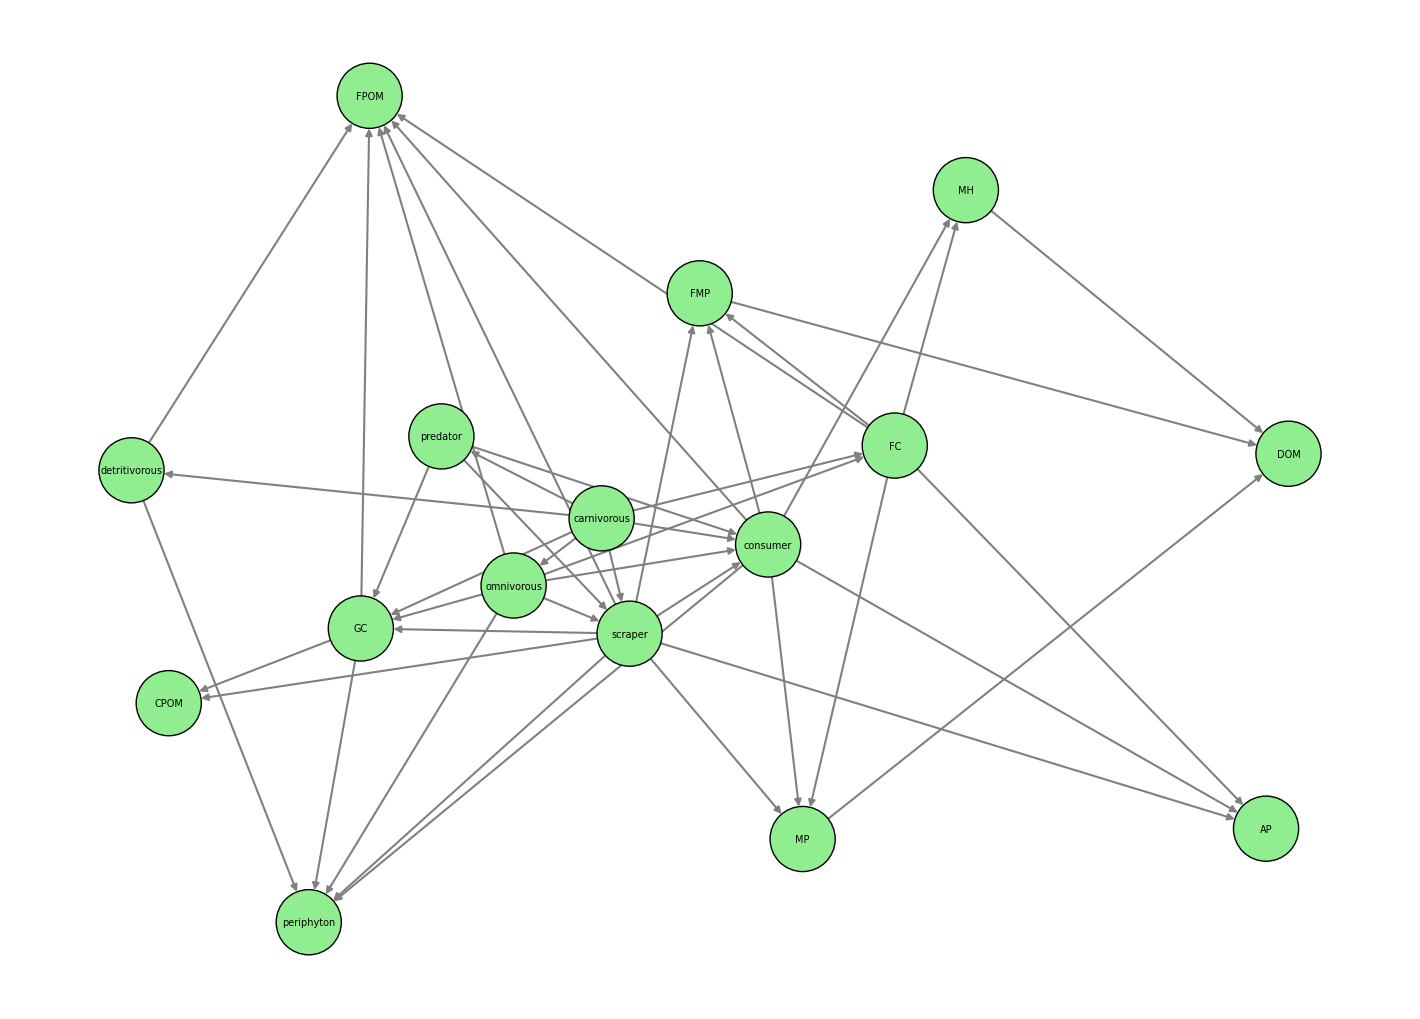

Número de nodos: 16
Número de enlaces: 43
Conectancia: 0.1792
Modularidad: 0.199

🔝 Nodos con mayor centralidad de grado:
scraper: 0.7333
consumer: 0.6667
gathering collector: 0.4667
filtering collector: 0.4667
omnivorous: 0.4667

🔗 Nodos con mayor intermediación (betweenness):
consumer: 0.0423
scraper: 0.033
filtering collector: 0.0187
gathering collector: 0.0121
mixotrophic phytoplankton: 0.011


In [ ]:
# Step 7: nodes
label_alias = {
    "autotrophic phytoplankton": "AP",
    "mixotrophic phytoplankton": "MP",
    "facultative mixotrophic phytoplankton": "FMP",
    "microbial heterotroph": "MH",
    "filtering collector": "FC",
    "gathering collector": "GC",
    "CPOM": "CPOM",
    "FPOM": "FPOM",
    "DOM": "DOM",
}

# Step 8: Define nodes to differentiate colors by group

grupo_nodo = {
    "DOM": "detritus",
    "FPOM": "detritus",
    "CPOM": "detritus",
      }

# Step 9: 📏 Size by functional group
tamaño_grupo = {
    "detritus": 2500,
    "microbial heterotroph": 2500,
    "periphyton": 2500,
    "consumer": 2500,
    "phytoplankton": 2500,
    "macroinvertebrate": 2500,
    "fish": 2500,
    "aquatic reptile": 2500
}

# Step 10: 🎨 Colours by functional group
colores_grupo = {
    "detritus": "saddlebrown",
    "microbial heterotroph": "goldenrod",
    "periphyton": "seagreen",
    "consumer": "skyblue",
    "autotrophic phytoplankton": "lightgreen",
    "mixotrophic phytoplankton": "green",
    "facultative mixotrophic phytoplankton": "blue",
    "macroinvertebrate": "moccasin",
    "fish": "lightcoral",
    "aquatic reptile": "lightgray"
}

# Step 11: Define nodes and links colours
node_colors = []
node_size = []
for node in G.nodes():
    if node == "shredder":
        node_colors.append("orangered")
        node_size.append(2200)
    else:
        node_colors.append("lightgreen")
        node_size.append(2200)

edge_colors = []
for u, v in G.edges():
    if "shredder" in (u, v):
        edge_colors.append("orangered")
    else:
        edge_colors.append("gray")

# Step 12: Visualization
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=1.0)  # k higher = less close
nx.draw(
    G,
    pos,
    with_labels=True,
    labels={n: label_alias.get(n, n) for n in G.nodes()},
    node_color=node_colors,
    node_size=node_size,
    edge_color=edge_colors,
    arrows=True,
    font_size=7,
    #font_weight='bold',
    edgecolors='black',
    width=1.5
)
#plt.title("Functional food web", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

# Step 13: Show metrics
print("Number of nodes:", num_nodes)
print("Number of links:", num_edges)
print("Conectance:", round(connectance, 4))
print("Modularity:", round(modularity, 4))

# Step 14: More important nodes
top_central = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("\n🔝 Nodes with more grade centrality:")
for node, value in top_central:
    print(f"{node}: {round(value, 4)}")

print("\n🔗 Nodes with more betweenness:")
for node, value in top_between:
    print(f"{node}: {round(value, 4)}")